In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax

from pyscf import ao2mo, gto, scf, fci, lo
import matplotlib.pyplot as plt

from libdet import Hamiltonian
from detnqs.model import Backflow, RBackflow
from detnqs.vstate import MCState
from detnqs.sampler import MCSampler
from detnqs.driver import VMC
from detnqs.optimizer import psr
from detnqs import utils

utils.batch.configure(chunk=8192)
utils.precision.configure("single")
jax.config.update("jax_debug_nans", False)
jax.config.update("jax_log_compiles", False)

In [2]:
mol = gto.M(
    atom="; ".join([f"H 0 0 {i * 2.00}" for i in range(10)]),
    basis="sto-6g",
    unit="Angstrom",
    verbose=0,
)
mf = scf.RHF(mol).run()
norb = mf.mo_coeff.shape[1]
n_alpha, n_beta = mol.nelec

# Orthonormalized Atomic Orbitals (OAOs)
C = lo.orth.orth_ao(mol, 'lowdin')
h1e = C.T @ mf.get_hcore() @ C
eri = ao2mo.restore(8, ao2mo.kernel(mol, C), mol.nao_nr())
h1e[abs(h1e) < 1e-6] = eri[abs(eri) < 1e-6] = 0.0
mo_coeff = np.linalg.solve(C, mf.mo_coeff)

ref_mat = np.zeros((n_alpha + n_beta, 2 * norb))
ref_mat[:n_alpha, :norb] = mo_coeff[:, :n_alpha].T
ref_mat[n_alpha:, norb:] = mo_coeff[:, :n_beta].T

ham = Hamiltonian.rhf(h1e, eri, ecore=mol.energy_nuc())

# e_fci = -7.66652801326695

solver = fci.direct_spin0.FCI(mol)
e_fci, ci = solver.kernel(h1e, eri, norb, mol.nelec, ecore=mol.energy_nuc())
s2, mult = fci.spin_op.spin_square(ci, norb, mol.nelec)

print(f"SCF energy : {mf.e_tot:.12f}")
print(f"FCI energy : {e_fci:.12f}")
print(f"S^2  : {s2:.6f}")

SCF energy : -3.999817969532
FCI energy : -4.790991828654
S^2  : 0.000000


In [3]:
model = RBackflow(norb=norb, n_alpha=n_alpha, n_beta=n_beta, hidden=(64,), ref_mat=jnp.array(ref_mat))

sampler = MCSampler(
    n_samples=1024,
    n_chains=1024,
    thermal_steps=1024,
    proposal="ham",
    blur=0.5,
)

state = MCState.init(
    model=model,
    hamiltonian=ham,
    sampler=sampler,
    n_alpha=n_alpha,
    n_beta=n_beta,
    init_method="random",
    key=jax.random.key(0),
)

optimizer = optax.chain(
    psr(shift=1e-2),
    optax.scale(-5e-2)
)

steps = 3000

E0609 00:07:44.855664  148435 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0609 00:07:44.867240  147846 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


--------------------------------------------------------------------------------------------------------
Step        Energy         |E-E0|       Var        Acc      ESS      N_u      N_f     alpha    SR cond  
--------------------------------------------------------------------------------------------------------
  0      -4.02922010      7.62e-01    2.78e-01    78.4%    49.3%     971     27449    1.000    3.93e+03 
 10      -4.29004145      5.01e-01    1.53e-01    52.5%    82.5%     942     24846    1.861    2.50e+05 
 20      -4.51702023      2.74e-01    1.01e-01    38.5%    76.6%     839     21996    1.909    4.70e+04 
 30      -4.66627026      1.25e-01    5.95e-02    28.9%    68.6%     718     18682    1.886    2.32e+04 
 40      -4.73587322      5.51e-02    3.76e-02    22.0%    62.5%     645     16498    1.834    2.15e+04 
 50      -4.76752138      2.35e-02    1.81e-02    18.0%    56.6%     604     15664    1.773    2.36e+03 
 60      -4.77974033      1.13e-02    6.83e-03    17.6%

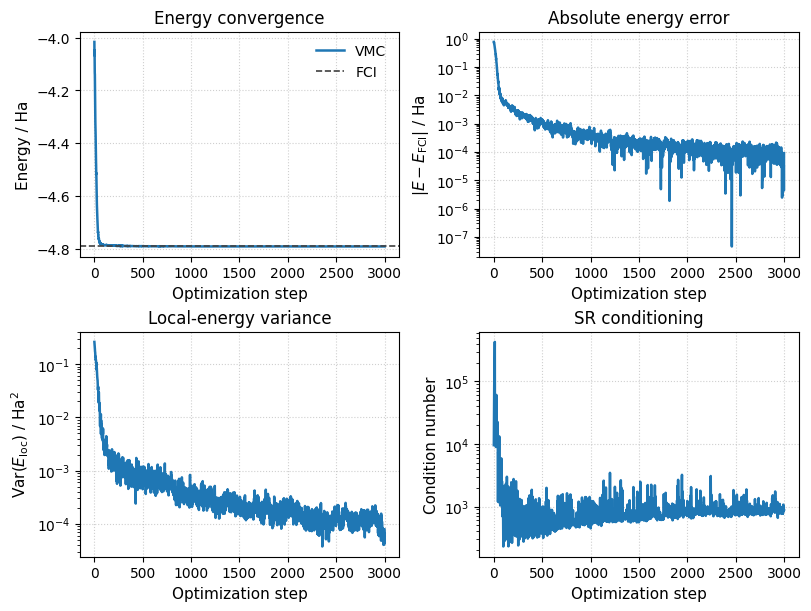

In [4]:
from collections import defaultdict

METRICS = {
    "step":     ("Step",    "d",    5),
    "energy":   ("Energy",  ".8f", 16),
    "error":    ("|E-E0|", ".2e", 10),
    "variance": ("Var",    ".2e", 10),
    "accept":   ("Acc",    ".1%",  7),
    "ess_frac": ("ESS",    ".1%",  7),
    "n_unique": ("N_u",    ".0f",  7),
    "n_eval":   ("N_f",    ".0f",  7),
    "alpha":    ("alpha",  ".3f",  7),
    "sr_cond":  ("SR cond", ".2e", 10),
}

header = "  ".join(f"{label:^{width}}" for label, _, width in METRICS.values())
line = "-" * len(header)
print(line, header, line, sep="\n")


vmc = VMC.init(state, optimizer)
history = []
total_times = defaultdict(float)

for step in range(steps):
    stats = dict(vmc.step())
    stats["step"] = step
    stats["error"] = abs(float(stats["energy"]) - e_fci)
    history.append(stats)

    for key, value in stats.items():
        if key.startswith("time_"):
            total_times[key.removeprefix("time_")] += float(value)

    if step % 10 == 0 or step == steps - 1:
        row = []
        for key, (_, fmt, width) in METRICS.items():
            value = stats.get(key, np.nan)
            text = f"{int(value):{fmt}}" if fmt == "d" else f"{float(value):{fmt}}"
            row.append(f"{text:^{width}}")
        print("  ".join(row))

print(line)

if total_times:
    times = sorted(
        (item for item in total_times.items() if item[0] != "total"),
        key=lambda item: item[1],
        reverse=True,
    )
    print("Time:", "  ".join(f"{key}={value:.2f}s" for key, value in times))
    print(line)


# Convert history to arrays
hist = {
    key: np.asarray([record.get(key, np.nan) for record in history], dtype=float)
    for key in METRICS
}

mask = hist["step"] > 0
x = hist["step"][mask]

energy = hist["energy"][mask]
error = np.clip(hist["error"][mask], 1e-16, None)
variance = np.clip(hist["variance"][mask], 1e-16, None)
sr_cond = np.where(hist["sr_cond"][mask] > 0, hist["sr_cond"][mask], np.nan)


# Plot
fig, axes = plt.subplots(2, 2, figsize=(8, 6), constrained_layout=True)
axes = axes.ravel()

ax = axes[0]
ax.plot(x, energy, lw=1.8, label="VMC")
ax.axhline(e_fci, ls="--", lw=1.2, color="0.25", label="FCI")
ax.set(
    title="Energy convergence",
    xlabel="Optimization step",
    ylabel="Energy / Ha",
)
ax.legend(frameon=False)

ax = axes[1]
ax.semilogy(x, error, lw=1.8)
ax.set(
    title="Absolute energy error",
    xlabel="Optimization step",
    ylabel=r"$|E - E_\mathrm{FCI}|$ / Ha",
)

ax = axes[2]
ax.semilogy(x, variance, lw=1.8)
ax.set(
    title="Local-energy variance",
    xlabel="Optimization step",
    ylabel=r"$\mathrm{Var}(E_\mathrm{loc})$ / Ha$^2$",
)

ax = axes[3]
if np.isfinite(sr_cond).any():
    ax.semilogy(x, sr_cond, lw=1.8)
else:
    ax.text(
        0.5, 0.5, "SR condition unavailable",
        ha="center", va="center",
        transform=ax.transAxes,
    )
ax.set(
    title="SR conditioning",
    xlabel="Optimization step",
    ylabel="Condition number",
)

for ax in axes:
    ax.grid(True, which="major", ls=":", alpha=0.6)
    ax.tick_params(labelsize=10)
    ax.title.set_size(12)
    ax.xaxis.label.set_size(11)
    ax.yaxis.label.set_size(11)

plt.show()